In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [3]:
#Define the evaluation function here
def evaluate(model_name, y_true, y_pred):

  print("\n")
  print("="*40)
  print(model_name)
  print("="*40)

  print("Accuracy :", accuracy_score(y_true, y_pred))
  print("Precision :", precision_score(y_true, y_pred))
  print("Recall :", recall_score(y_true, y_pred))
  print("F1 Score :", f1_score(y_true, y_pred))
  print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

In [4]:
data = load_breast_cancer()

x = data.data
y = data.target

print("Dataset Shape: ", x.shape)
print("Classes: ", np.unique(y))

Dataset Shape:  (569, 30)
Classes:  [0 1]


In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=38,
    stratify=y
  )

In [6]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [7]:
mle_model = LogisticRegression(
    penalty = None,
    max_iter = 5000,
    random_state = 38
)

mle_model.fit(x_train, y_train)
y_pred_mle = mle_model.predict(x_test)

In [8]:
map_l2 = LogisticRegression(
    penalty = 'l2',
    C = 1.0,
    solver = 'lbfgs',

    max_iter = 5000,
    random_state = 38
)

map_l2.fit(x_train,y_train)
y_pres_l2 = map_l2.predict(x_test)

In [9]:
map_l1 = LogisticRegression(
    penalty = 'l1',
    solver = 'liblinear',
    C = 1.0,
    max_iter = 5000,
    random_state = 38
)

map_l1.fit(x_train, y_train)
y_pred_l1 = map_l1.predict(x_test)

In [10]:
evaluate("MLE Model", y_test, y_pred_mle)
evaluate("MAP (L2)", y_test, y_pres_l2)
evaluate("MAP (L1)", y_test, y_pred_l1)



MLE Model
Accuracy : 0.9532163742690059
Precision : 0.9714285714285714
Recall : 0.9532710280373832
F1 Score : 0.9622641509433962
Confusion matrix:
 [[ 61   3]
 [  5 102]]


MAP (L2)
Accuracy : 0.9824561403508771
Precision : 0.9814814814814815
Recall : 0.9906542056074766
F1 Score : 0.986046511627907
Confusion matrix:
 [[ 62   2]
 [  1 106]]


MAP (L1)
Accuracy : 0.9883040935672515
Precision : 0.981651376146789
Recall : 1.0
F1 Score : 0.9907407407407407
Confusion matrix:
 [[ 62   2]
 [  0 107]]


In [11]:
print("Number of Zero Coefficients")
print("MLE: ", np.sum(mle_model.coef_[0] == 0))
print("MAP L2: ", np.sum(map_l2.coef_[0] == 0))
print("MAP L1: ", np.sum(map_l1.coef_[0] == 0))

Number of Zero Coefficients
MLE:  0
MAP L2:  0
MAP L1:  13


In [12]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])
models = [
    ("MLE Model", mle_model, y_pred_mle),
    ("MAP (L2)", map_l2, y_pres_l2),
    ("MAP (L1)", map_l1, y_pred_l1)
]
for name, model, pred in models:
  results.loc[len(results)] = [
      name,
      accuracy_score(y_test, pred),
      precision_score(y_test, pred),
      recall_score(y_test, pred),
      f1_score(y_test, pred)
  ]

print(results)

       Model  Accuracy  Precision    Recall  F1 Score
0  MLE Model  0.953216   0.971429  0.953271  0.962264
1   MAP (L2)  0.982456   0.981481  0.990654  0.986047
2   MAP (L1)  0.988304   0.981651  1.000000  0.990741


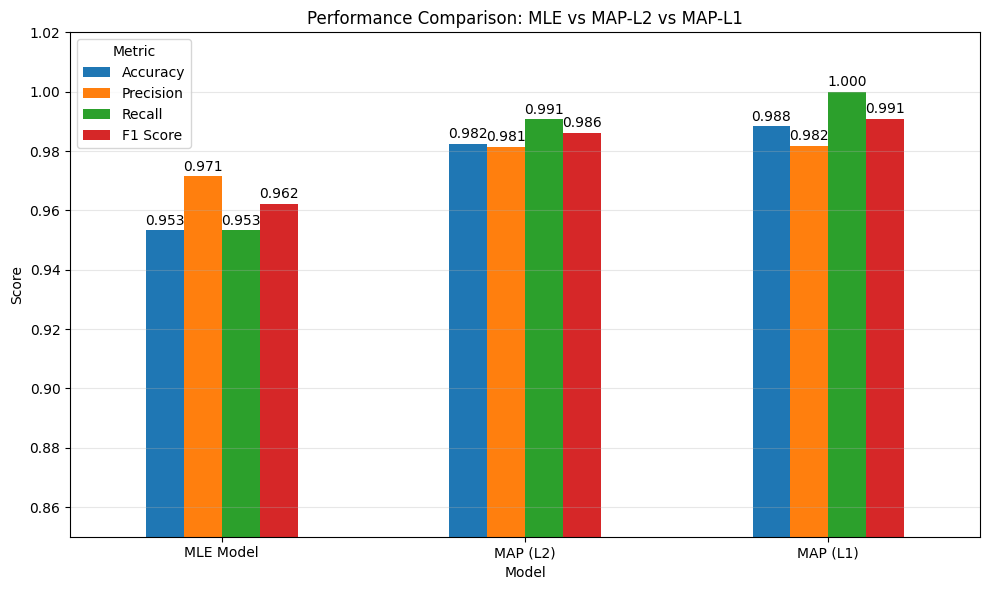

In [13]:
ax = results.set_index("Model").plot(
    kind = "bar",
    figsize = (10,6)
)
plt.title("Performance Comparison: MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.02)
plt.xticks(rotation = 0)
plt.legend(title = "Metric")
plt.grid(axis = "y", alpha = 0.3)

#Show values on bars
for container in ax.containers:
  ax.bar_label(container, fmt = "%.3f", padding = 2)

plt.tight_layout()
plt.show()

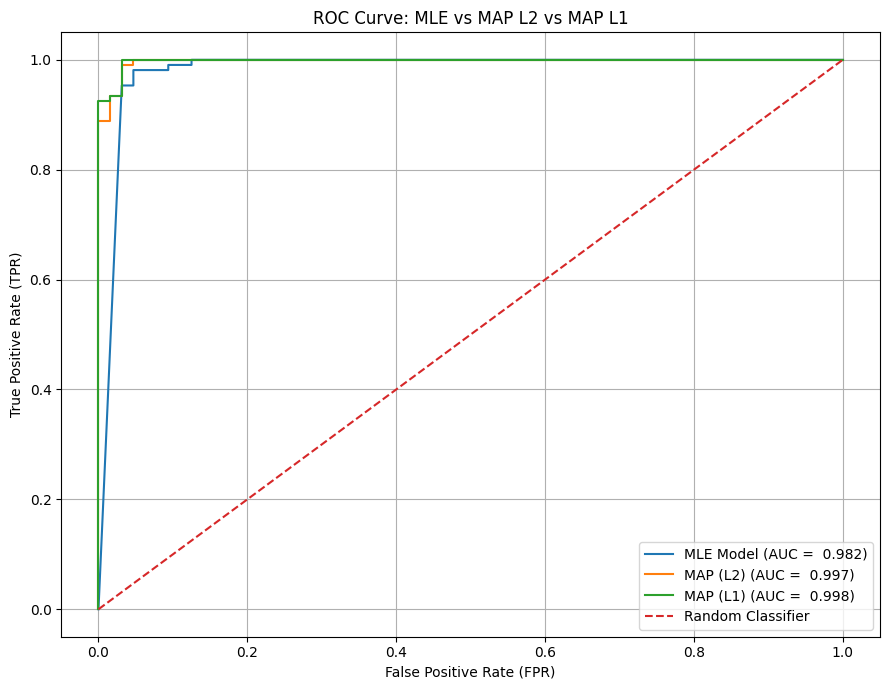

In [14]:
plt.figure(figsize=(9,7))
for name, model, pred in models:
  #Predicted probability for positive class
  y_prob = model.predict_proba(x_test)[:,1] #Gives the probability of each class

  #Calculate ROC values
  fpr, tpr, thresholds = roc_curve(y_test, y_prob)

  #Calculate AUC
  roc_auc = auc(fpr, tpr)

  #Plot ROC Curve
  plt.plot(
      fpr,
      tpr,
      label = f"{name} (AUC = {roc_auc: .3f})"
  )

  #Random Classifier refernce line
plt.plot(
    [0,1],
    [0,1],
    linestyle = "--",
    label = "Random Classifier"
)
# #Zoom into the useful region
# plt.xlim(0, 0.15)
# plt.ylim(0.75, 1.01)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()